In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import backend as K    
from tensorflow.keras import Input,Model
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Dense,Dropout,GlobalAveragePooling2D
from tensorflow.keras.metrics import AUC
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
import os
import glob
from functools import partial
from kaggle_secrets import UserSecretsClient
import math
from datetime import datetime
import random

try:
    import wandb
except:
    !pip install --upgrade -q wandb
    import wandb
from wandb.keras import WandbCallback


now = datetime.now()
date = now.strftime("%Y %m %d")

In [2]:
# set seed for reproducibility
tf.keras.utils.set_random_seed(42)
random.seed(42)
np.random.seed(42)

In [3]:
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs: {strategy.num_replicas_in_sync}")

Number of GPUs: 2


In [4]:
class C:
    raw_path = "/kaggle/input/gsoc-data"
    train_data = os.path.join(raw_path,"dataset/train")
    val_data = os.path.join(raw_path,"dataset/val")
    weights = f"weights_{date}.h5"
    num_classes = 3
    epochs = 20
    batch_size = 256
    height = 150
    shape = [height,height]
    base_lr = 1e-4
    autotune = tf.data.experimental.AUTOTUNE
    buffer = 1024
    

In [7]:
# wandb setup
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("my_dash")
!wandb login $secret_value_0

wandb.init(
    project="GSOC23_DeepLense_Test",
    config={
        "learning_rate": C.base_lr,
        "lr schedule" : "None",
        "batch_size": C.batch_size,
        "image_dim": C.height,
        "augmentation scheme": "image translation and rotation",
        "model": "Resnet50"
    },
    group = "Test 1",
    job_type = "supervised"
)

wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


wandb: Currently logged in as: atiaisaac007. Use `wandb login --relogin` to force relogin


In [8]:
def data_generator(file_path):
  classes = tf.constant(["no","sphere","vort"])
  for fn in file_path:
    f = np.reshape(np.load(fn),(*C.shape,1))
    f = np.tile(f,(1,1,3))
    for j in range(len(classes)):
      if classes[j].numpy() in fn:
        label = j
        break
    yield f, np.array(np.eye(C.num_classes)[j])

In [9]:
no_train = glob.glob(os.path.join(C.train_data,"no/*"))
sphere_train = glob.glob(os.path.join(C.train_data,"sphere/*"))
vort_train = glob.glob(os.path.join(C.train_data,"vort/*"))

no_val = glob.glob(os.path.join(C.val_data,"no/*"))
sphere_val = glob.glob(os.path.join(C.val_data,"sphere/*"))
vort_val = glob.glob(os.path.join(C.val_data,"vort/*"))

train_files = no_train + sphere_train + vort_train
val_files = no_val + sphere_val + vort_val

np.random.shuffle(train_files)
np.random.shuffle(val_files)

In [10]:
train_ds = tf.data.Dataset.from_generator(
    data_generator,args = (train_files,),
    output_signature=(
        tf.TensorSpec(shape=(*C.shape,3),dtype=tf.float32),
        tf.TensorSpec(shape=(3),dtype=tf.float32)
    )
)

val_ds = tf.data.Dataset.from_generator(
    data_generator, args = (val_files,),
    output_signature=(
        tf.TensorSpec(shape=(*C.shape,3),dtype=tf.float32),
        tf.TensorSpec(shape=(3),dtype=tf.float32)
    )
)

In [11]:
def visualize(x,y,title):
  plt.figure(figsize=(10, 10)).suptitle(title,fontsize=18)
  for n in range(25):
      ax = plt.subplot(5, 5, n + 1)
      plt.imshow(x[n].numpy())
      if y is not None:
        plt.title(y[n].numpy())
      plt.axis("off")
  plt.show()

/opt/conda/lib/python3.7/site-packages/matplotlib/text.py:1223: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if s != self._text:


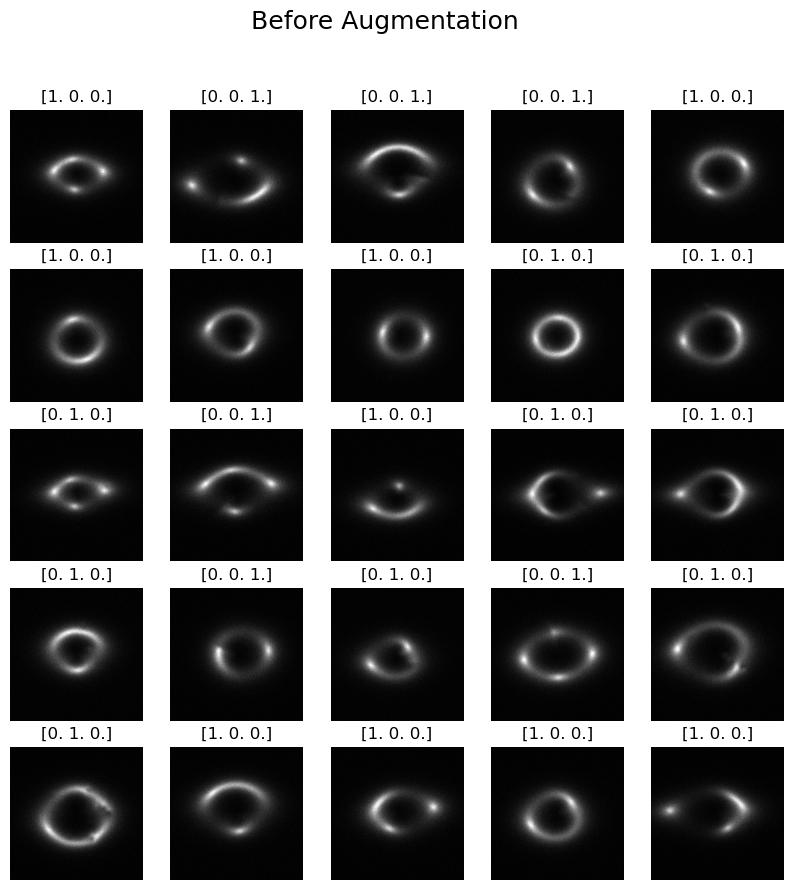

In [12]:
train_x,train_y = next(iter(train_ds.batch(C.batch_size).take(1)))
visualize(train_x,train_y,"Before Augmentation")

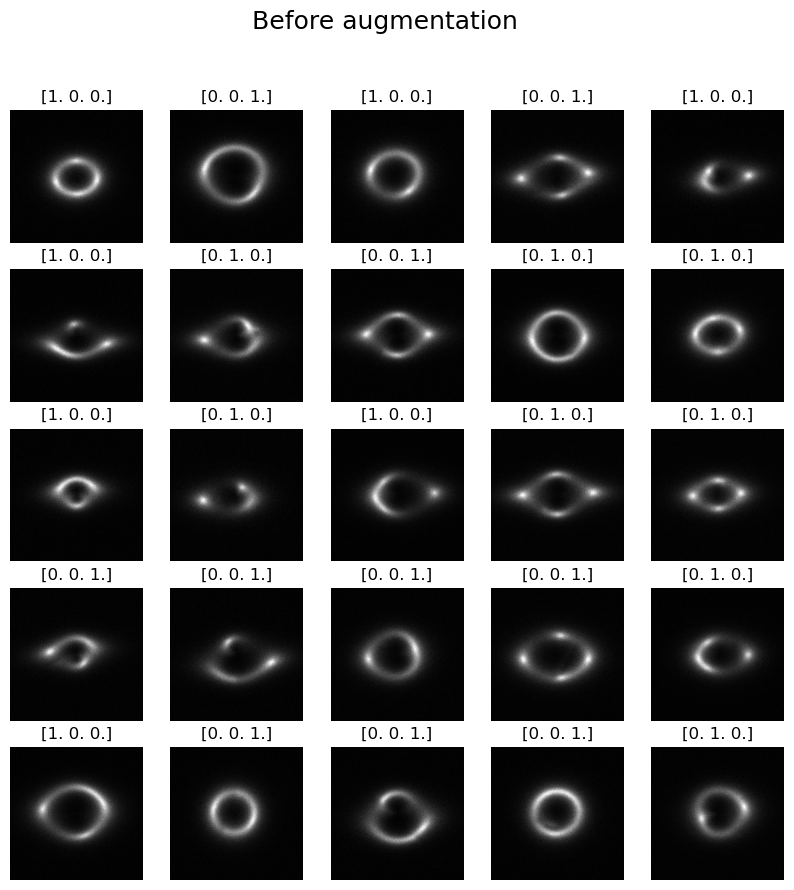

In [13]:
val_x,val_y = next(iter(val_ds.batch(C.batch_size).take(1)))
visualize(val_x,val_y,"Before augmentation")

In [14]:
# data augmentation @cdeotte kernel: https://www.kaggle.com/cdeotte/rotation-augmentation-gpu-tpu-0-96
def transform_rotation(image, height, rotation):
    # input image - is one image of size [dim,dim,3] not a batch of [b,dim,dim,3]
    # output - image randomly rotated
    DIM = height
    XDIM = DIM%3 #fix for size 331
    
    rotation = rotation * tf.random.uniform([1],dtype='float32')
    # CONVERT DEGREES TO RADIANS
    rotation = math.pi * rotation / 180.
    
    # ROTATION MATRIX
    c1 = tf.math.cos(rotation)
    s1 = tf.math.sin(rotation)
    one = tf.constant([1],dtype='float32')
    zero = tf.constant([0],dtype='float32')
    rotation_matrix = tf.reshape(tf.concat([c1,s1,zero, -s1,c1,zero, zero,zero,one],axis=0),[3,3])

    # LIST DESTINATION PIXEL INDICES
    x = tf.repeat( tf.range(DIM//2,-DIM//2,-1), DIM )
    y = tf.tile( tf.range(-DIM//2,DIM//2),[DIM] )
    z = tf.ones([DIM*DIM],dtype='int32')
    idx = tf.stack( [x,y,z] )
    
    # ROTATE DESTINATION PIXELS ONTO ORIGIN PIXELS
    idx2 = K.dot(rotation_matrix,tf.cast(idx,dtype='float32'))
    idx2 = K.cast(idx2,dtype='int32')
    idx2 = K.clip(idx2,-DIM//2+XDIM+1,DIM//2)
    
    # FIND ORIGIN PIXEL VALUES 
    idx3 = tf.stack( [DIM//2-idx2[0,], DIM//2-1+idx2[1,]] )
    d = tf.gather_nd(image, tf.transpose(idx3))
        
    return tf.reshape(d,[DIM,DIM,3])

In [15]:
def augment(x,y,train=True):
    if train:
        x = transform_rotation(x,C.height,45.)
        x = tf.image.rot90(x,k=2)
    x = tf.clip_by_value(x,0.,1.)
    return x,y

aug_train = train_ds.map(partial(augment,train=True),num_parallel_calls=C.autotune)
aug_train = aug_train.repeat().shuffle(C.buffer).batch(C.batch_size).prefetch(C.autotune)

aug_val = val_ds.map(partial(augment,train=False),num_parallel_calls=C.autotune)
aug_val = aug_val.repeat().batch(C.batch_size).prefetch(C.autotune)

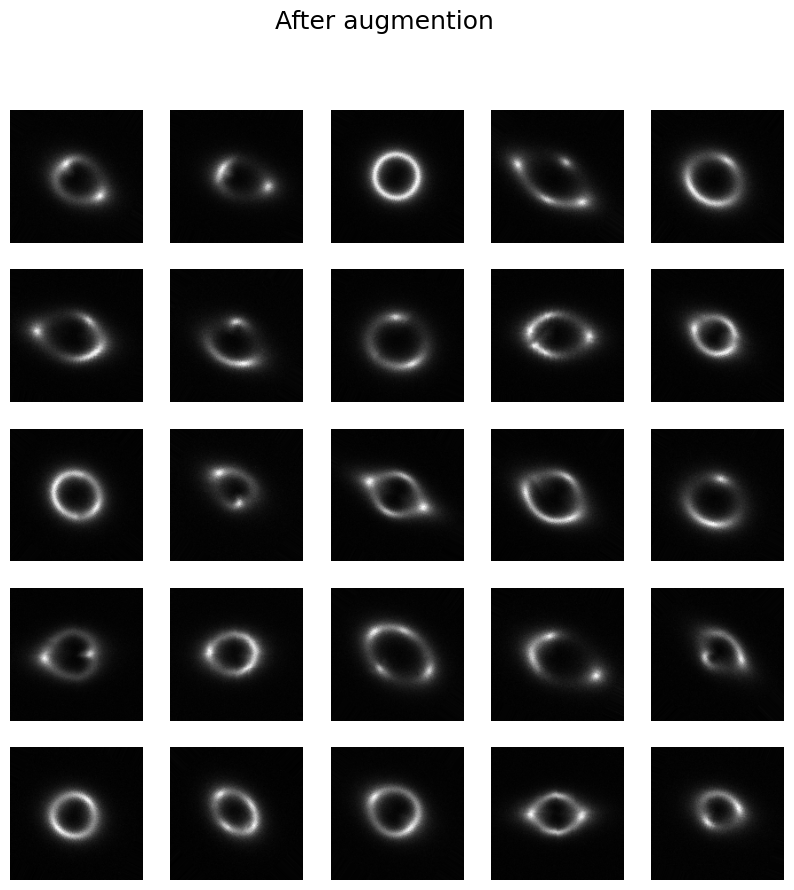

In [16]:
dum_x,dum_y = next(iter(aug_train.take(1)))
visualize(dum_x,None,"After augmention")

In [17]:
steps_per_epoch = int(np.ceil(30000 / C.batch_size))
validation_steps = int(np.ceil(7500 / C.batch_size))

In [18]:
def get_model():
  inp = Input(shape=[*C.shape,3])
  base = tf.keras.applications.resnet50.ResNet50(
      weights = "imagenet",
      include_top = False,
      input_shape = [*C.shape,3],
  )
  base.trainable = True
  x = tf.keras.applications.resnet.preprocess_input(inp)
  x = base(x,training=True)
  x = GlobalAveragePooling2D()(x)
  out = Dense(C.num_classes,activation="softmax")(x)
  model = Model(inputs=inp,outputs=out)
  model.compile(
      loss = tf.keras.losses.CategoricalCrossentropy(),
      optimizer = tf.keras.optimizers.Adam(
          learning_rate = C.base_lr,
#           weight_decay = C.decay
      ),
      metrics = AUC()
  )
  return model

In [19]:
with strategy.scope():
    deeplense_model = get_model()
#     schedule = ReduceLROnPlateau(
#         monitor = "val_auc",
#         patience = 3,
#         factor = 0.1
#     )
deeplense_model.summary()

94765736/94765736 [==============================] - 1s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 tf.__operators__.getitem (S  (None, 150, 150, 3)      0         
 licingOpLambda)                                                 
                                                                 
 tf.nn.bias_add (TFOpLambda)  (None, 150, 150, 3)      0         
                                                                 
 resnet50 (Functional)       (None, 5, 5, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                              

In [20]:
deeplense_model.fit(
    aug_train,
    steps_per_epoch = steps_per_epoch,
    validation_data = aug_val,
    validation_steps = validation_steps, 
    epochs = C.epochs,
    callbacks = [WandbCallback()],
    verbose = 1
)

wandb: WARNING The save_model argument by default saves the model in the HDF5 format that cannot save custom objects like subclassed models and custom layers. This behavior will be deprecated in a future release in favor of the SavedModel format. Meanwhile, the HDF5 model is saved as W&B files and the SavedModel as W&B Artifacts.


Epoch 1/20
118/118 [==============================] - ETA: 0s - loss: 1.1372 - auc: 0.5021

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230321_132757-4x4tu9hk/files/model-best)... Done. 1.6s


118/118 [==============================] - 490s 3s/step - loss: 1.1372 - auc: 0.5021 - val_loss: 1.1563 - val_auc: 0.5036
Epoch 2/20
118/118 [==============================] - ETA: 0s - loss: 1.1166 - auc: 0.5031

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230321_132757-4x4tu9hk/files/model-best)... Done. 1.5s


...

118/118 [==============================] - 274s 2s/step - loss: 0.3052 - auc: 0.9744 - val_loss: 0.3885 - val_auc: 0.9601
Epoch 18/20
118/118 [==============================] - ETA: 0s - loss: 0.2898 - auc: 0.9768

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230321_132757-4x4tu9hk/files/model-best)... Done. 2.4s


118/118 [==============================] - 263s 2s/step - loss: 0.2898 - auc: 0.9768 - val_loss: 0.3813 - val_auc: 0.9609
Epoch 19/20
118/118 [==============================] - ETA: 0s - loss: 0.2804 - auc: 0.9783

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230321_132757-4x4tu9hk/files/model-best)... Done. 2.5s


118/118 [==============================] - 257s 2s/step - loss: 0.2804 - auc: 0.9783 - val_loss: 0.3649 - val_auc: 0.9646
Epoch 20/20
118/118 [==============================] - 194s 2s/step - loss: 0.2609 - auc: 0.9811 - val_loss: 0.3758 - val_auc: 0.9643


In [21]:
deeplense_model.evaluate(aug_val,steps=validation_steps)

30/30 [==============================] - 42s 1s/step - loss: 0.3758 - auc: 0.9643


[0.3757931888103485, 0.9642706513404846]

In [22]:
deeplense_model.save_weights(os.path.join(wandb.run.dir,C.weights))

In [23]:
deeplense_model.save_weights(C.weights)